## Introduction

This notebook uses the preprocessed spectrogram dataset generated in the preprocessing stage to train and evaluate a baseline convolutional neural network.
The task is framed as a binary classification problem, distinguishing between Rupe A and Rupe B grey seal vocalisations.

A simple CNN architecture is used to establish a baseline level of performance, with evaluation performed using accuracy, classification metrics, and a confusion matrix.

## Load dataset (NPZ)

### Imports + project root

In [27]:
# X loaded from NPZ should be (N, 6, 115) or (N, 6, 115, 1)
# Force it to (N, 6, 115, 1) exactly once.

import numpy as np

while X.ndim > 4 and X.shape[-1] == 1:
    X = np.squeeze(X, axis=-1)

if X.ndim == 3:
    X = X[..., np.newaxis]

print("Normalised X:", X.shape)


Normalised X: (126, 6, 115, 1)


In [28]:
import numpy as np
from pathlib import Path

# Because notebook is in /notebooks
PROJECT_ROOT = Path.cwd().parent
DATASET_PATH = PROJECT_ROOT / "data_processed" / "dataset_rupeA_rupeB_v1.npz"

DATASET_PATH, DATASET_PATH.exists()


(WindowsPath('c:/repos/finalproject-hugcamrom/data_processed/dataset_rupeA_rupeB_v1.npz'),
 True)

### Load and inspect

In [29]:
loaded = np.load(DATASET_PATH, allow_pickle=True)

X = loaded["X"]          # (N, 6, 115)
y = loaded["y"]          # (N,)
label_map = loaded["label_map"]  # array of tuples
target_shape = loaded["target_shape"]

X.shape, y.shape, label_map, target_shape


((126, 6, 115),
 (126,),
 array([['Rupe A', 0],
        ['Rupe B', 1]], dtype=object),
 array([  6, 115], dtype=int64))

## Train/validation/test split

In [30]:
# Split dataset

from sklearn.model_selection import train_test_split

# Add channel dimension for CNN: (N, 6, 115, 1)
X = X[..., np.newaxis].astype(np.float32)
y = y.astype(np.int64)

# Train+Val vs Test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train vs Val
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=42, stratify=y_trainval
)

X_train.shape, X_val.shape, X_test.shape



((80, 6, 115, 1), (20, 6, 115, 1), (26, 6, 115, 1))

## Baseline CNN model

In [31]:
# inspect shapes before building the model

X.shape, X_train.shape


((126, 6, 115, 1), (80, 6, 115, 1))

In [32]:
# Add channel dimension

# Ensure X is a flote32
X = X.astype(np.float32)

# Add channel dim only if needed
if X.ndim == 3:          # (N, 6, 115)
    X = X[..., np.newaxis]  # -> (N, 6, 115, 1)

elif X.ndim == 5 and X.shape[-1] == 1:  # (N, 6, 115, 1, 1)
    X = X.squeeze(-1)    # -> (N, 6, 115, 1)



In [21]:

import tensorflow as tf
tf.__version__
from tensorflow import keras

In [33]:
# Baseline model: Simple and Fast CNN

import tensorflow as tf
from tensorflow.keras import layers, models

input_shape = X_train.shape[1:]  # (6, 115, 1)

model = models.Sequential([
    layers.Input(shape=input_shape),

    layers.Conv2D(16, (3, 3), padding="same", activation="relu"),
    layers.MaxPool2D((2, 2)),

    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.MaxPool2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")  # binary
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 6, 115, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 3, 57, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 3, 57, 32)      │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 1, 28, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 896)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │        57,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,273 (243.25 KB)

 Trainable params: 62,273 (243.25 KB)

 Non-trainable params: 0 (0.00 B)

## Training

In [34]:
# Adding class weights to handle class imbalance and help training

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)
class_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight_dict = {int(c): float(w) for c, w in zip(classes, class_weights)}
class_weight_dict

{0: 0.8695652173913043, 1: 1.1764705882352942}

In [35]:
# train with early stopping

import tensorflow as tf

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=8, restore_best_weights=True
    )
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    class_weight=class_weight_dict,      # <-- add class weights here
    verbose=1
)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 182ms/step - accuracy: 0.6359 - loss: 2.3476 - val_accuracy: 0.8500 - val_loss: 1.1778
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9156 - loss: 0.9799 - val_accuracy: 0.9000 - val_loss: 1.6544
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8711 - loss: 1.6466 - val_accuracy: 0.8500 - val_loss: 1.5152
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.8750 - loss: 1.1506 - val_accuracy: 0.8500 - val_loss: 1.4020
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9055 - loss: 0.7864 - val_accuracy: 0.8000 - val_loss: 1.1775
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9031 - loss: 0.4653 - val_accuracy: 0.8500 - val_loss: 0.9341
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9203 - loss: 0.4041 - val_accuracy: 0.8500 - val_loss: 0.7661
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9453 - loss: 0.3742 - val_accuracy: 0.7500 - val_loss

## Evaluation (metrics + confusion matrix)

In [39]:
# evaluate test set

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import numpy as np

y_pred_probs = model.predict(X_test).ravel()
y_pred = (y_pred_probs >= 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["Rupe A", "Rupe B"]))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Accuracy: 0.7692307692307693
              precision    recall  f1-score   support

      Rupe A       0.91      0.67      0.77        15
      Rupe B       0.67      0.91      0.77        11

    accuracy                           0.77        26
   macro avg       0.79      0.79      0.77        26
weighted avg       0.81      0.77      0.77        26

Confusion Matrix:
 [[10  5]
 [ 1 10]]


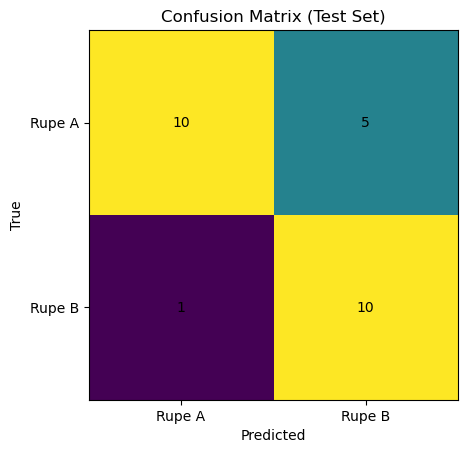

In [40]:
# plot confusion matrix

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix (Test Set)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks([0, 1], ["Rupe A", "Rupe B"])
plt.yticks([0, 1], ["Rupe A", "Rupe B"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.show()


The baseline CNN achieved a test accuracy of approximately 77% when classifying Rupe A and Rupe B vocalisations. The confusion matrix shows stronger recall for Rupe B calls, suggesting these calls have more distinctive spectral characteristics, while Rupe A calls exhibit greater variability. Given the small dataset size and limited model complexity, these results provide a strong baseline for further experimentation.

---

## Next steps

The baseline model provides a reference point for future improvements.
Potential extensions include experimenting with alternative architectures, data augmentation techniques, or incorporating additional vocalisation classes.
Further analysis could also explore the biological significance of misclassifications observed in the confusion matrix.

## References

- TensorFlow Developers. **Keras API documentation** (model building and training).  
  https://www.tensorflow.org/api_docs/python/tf/keras

- TensorFlow Developers. **`tf.keras.layers.Conv2D` documentation** (CNN layers used for spectrogram classification).  
  https://www.tensorflow.org/api_docs/python/tf/keras/layers/Conv2D

- scikit-learn Developers. **Classification metrics documentation** (`classification_report`, confusion matrix, etc.).  
  https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics


## Notes

- This notebook trains a **baseline CNN** for the binary classification task **Rupe A vs Rupe B**.  
- Evaluation is reported on a held-out test split using accuracy, precision/recall/F1, and a confusion matrix.  
- Further improvements (augmentation, model variants, additional classes) are listed in the **Next Steps** section.
